# Task 3 — CNN: CIFAR-10 Image Classification
**Dataset:** CIFAR-10 (torchvision / tf.keras)  
**Tools:** TensorFlow / Keras  
**Objective:** Design and train a CNN from scratch to classify 10 CIFAR-10 classes. Use at least 4 conv layers with pooling, apply data augmentation, visualize first-layer filters. Target ≥80% test accuracy.

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices("GPU")) > 0)

TensorFlow version: 2.20.0
GPU available: True


## 2. Load and Explore CIFAR-10

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train: (50000, 32, 32, 3), Test: (10000, 32, 32, 3)
Pixel range: [0, 255]


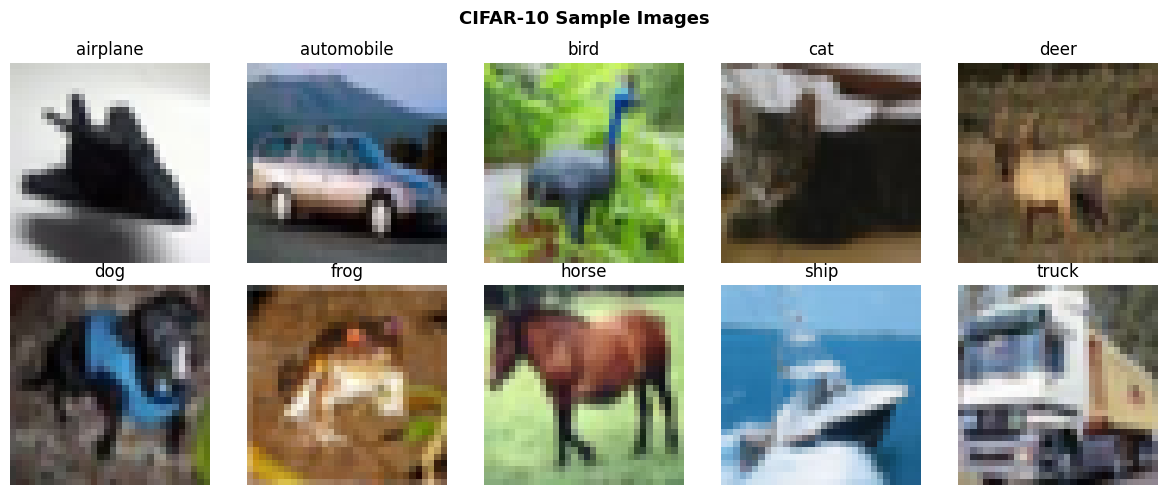

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Pixel range: [{X_train.min()}, {X_train.max()}]')

# Show sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('CIFAR-10 Sample Images', fontsize=13, fontweight='bold')
for i, ax in enumerate(axes.flat):
    idx = np.where(y_train.flatten() == i)[0][0]
    ax.imshow(X_train[idx])
    ax.set_title(CLASS_NAMES[i])
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Preprocessing

In [3]:
# Normalize to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

# One-hot encode labels
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat  = keras.utils.to_categorical(y_test,  10)

print('X_train range:', X_train.min(), '-', X_train.max())
print('y_train_cat shape:', y_train_cat.shape)

X_train range: 0.0 - 1.0
y_train_cat shape: (50000, 10)


## 4. Data Augmentation

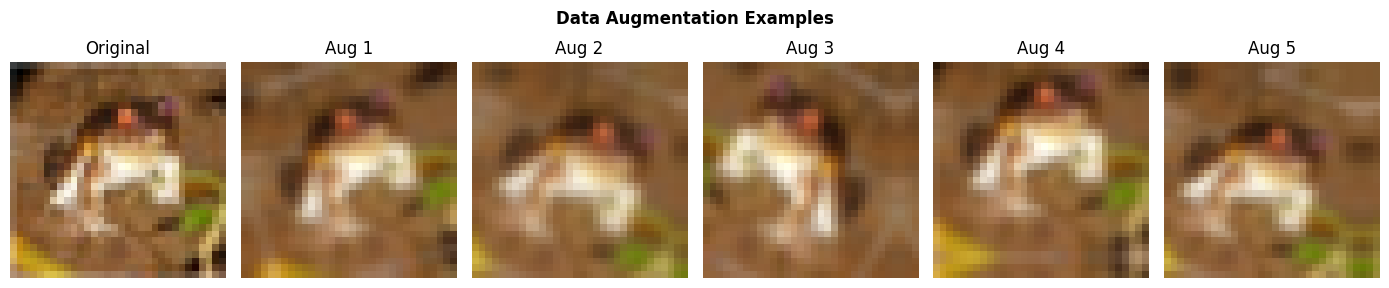

In [4]:
# Data augmentation pipeline
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.1),
], name='augmentation')

# Visualize augmentation effects
sample = X_train[:1]
fig, axes = plt.subplots(1, 6, figsize=(14, 3))
axes[0].imshow(sample[0]); axes[0].set_title('Original'); axes[0].axis('off')
for i in range(1, 6):
    aug = data_augmentation(sample, training=True)[0].numpy()
    aug = np.clip(aug, 0, 1)
    axes[i].imshow(aug); axes[i].set_title(f'Aug {i}'); axes[i].axis('off')
plt.suptitle('Data Augmentation Examples', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Build CNN Model (4 Conv Blocks)

In [5]:
def build_cnn():
    inputs = keras.Input(shape=(32, 32, 3))

    # Augmentation (only active during training)
    x = data_augmentation(inputs)

    # Conv Block 1
    x = layers.Conv2D(32, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    # Conv Block 2
    x = layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    # Conv Block 3
    x = layers.Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.35)(x)

    # Conv Block 4
    x = layers.Conv2D(256, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)

    # Fully Connected Head
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='CIFAR10_CNN')
    return model

model = build_cnn()
model.summary()

Model: "CIFAR10_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 653,354 (2.49 MB)

 Trainable params: 651,946 (2.49 MB)

 Non-trainable params: 1,408 (5.50 KB)

## 6. Compile and Train

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train, y_train_cat,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.7571 - loss: 0.8554 - val_accuracy: 0.7898 - val_loss: 0.7833 - learning_rate: 0.0010
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.7508 - loss: 0.8910 - val_accuracy: 0.7416 - val_loss: 0.9542 - learning_rate: 0.0010
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.7549 - loss: 0.8972 - val_accuracy: 0.7110 - val_loss: 1.1350 - learning_rate: 0.0010
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.7521 - loss: 0.9152 - val_accuracy: 0.7414 - val_loss: 0.9790 - learning_rate: 0.0010
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.7541 - loss: 0.9184 - val_accuracy: 0.7398 - val_loss: 0.9859 - learning_rate: 0.0010
Epoch 6/50
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7502 - loss: 0.9290
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.7534 - los

## 7. Evaluate on Test Set

In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f'Test Accuracy : {test_acc*100:.2f}%')
print(f'Test Loss     : {test_loss:.4f}')

if test_acc >= 0.80:
    print('Target of >=80% accuracy achieved!')
else:
    print(f'Note: {(0.80 - test_acc)*100:.1f}% below target — try more epochs or reduce dropout.')

Test Accuracy : 84.02%
Test Loss     : 0.6017
Target of >=80% accuracy achieved!


## 8. Learning Curves

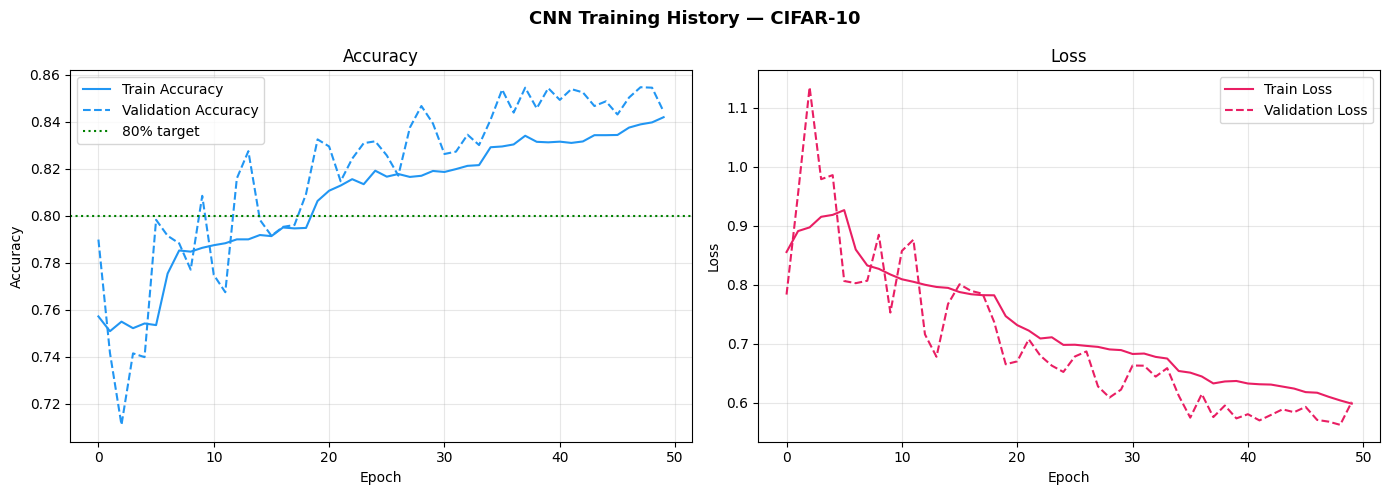

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN Training History — CIFAR-10', fontsize=13, fontweight='bold')

axes[0].plot(history.history['accuracy'],     label='Train Accuracy',      color='#2196F3')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy',  color='#2196F3', linestyle='--')
axes[0].axhline(0.80, color='green', linestyle=':', label='80% target')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train Loss',      color='#E91E63')
axes[1].plot(history.history['val_loss'], label='Validation Loss',  color='#E91E63', linestyle='--')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Per-Class Accuracy

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test.flatten()

print('Classification Report:')
print(classification_report(y_true, y_pred_classes, target_names=CLASS_NAMES))

Classification Report:
              precision    recall  f1-score   support

    airplane       0.87      0.85      0.86      1000
  automobile       0.89      0.95      0.92      1000
        bird       0.85      0.79      0.82      1000
         cat       0.80      0.67      0.73      1000
        deer       0.87      0.79      0.83      1000
         dog       0.88      0.68      0.77      1000
        frog       0.69      0.96      0.80      1000
       horse       0.87      0.90      0.88      1000
        ship       0.91      0.90      0.91      1000
       truck       0.84      0.91      0.88      1000

    accuracy                           0.84     10000
   macro avg       0.85      0.84      0.84     10000
weighted avg       0.85      0.84      0.84     10000



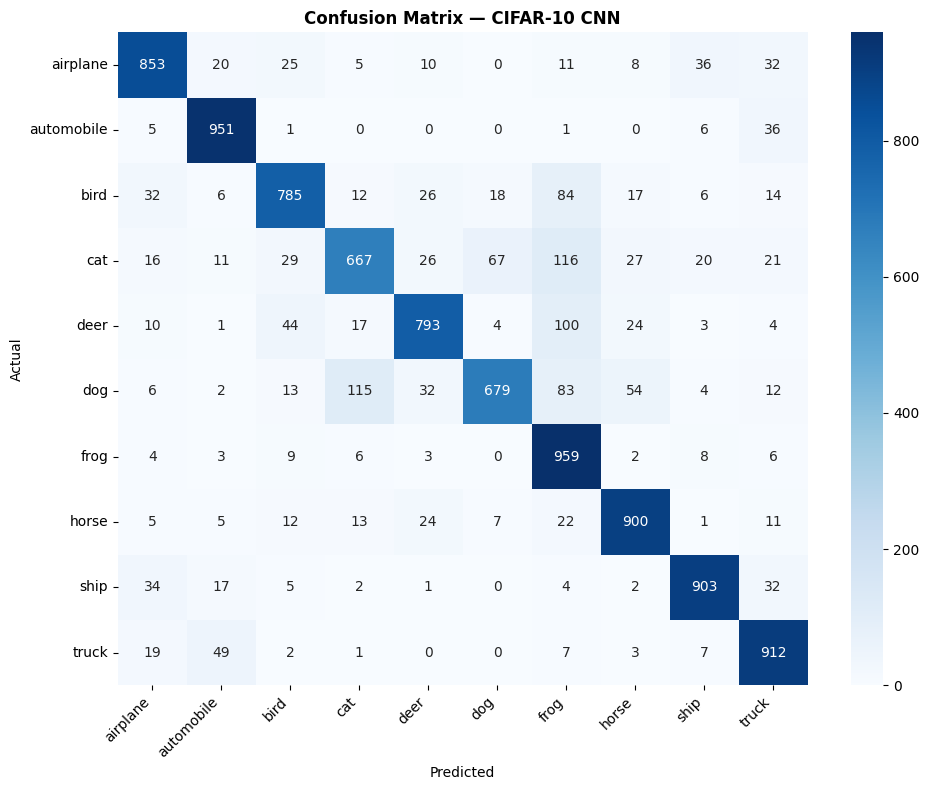

In [11]:
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — CIFAR-10 CNN', fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_cnn.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Visualize First-Layer Filters

First conv layer: conv2d
Filter shape: (3, 3, 3, 32)  (H x W x in_channels x n_filters)


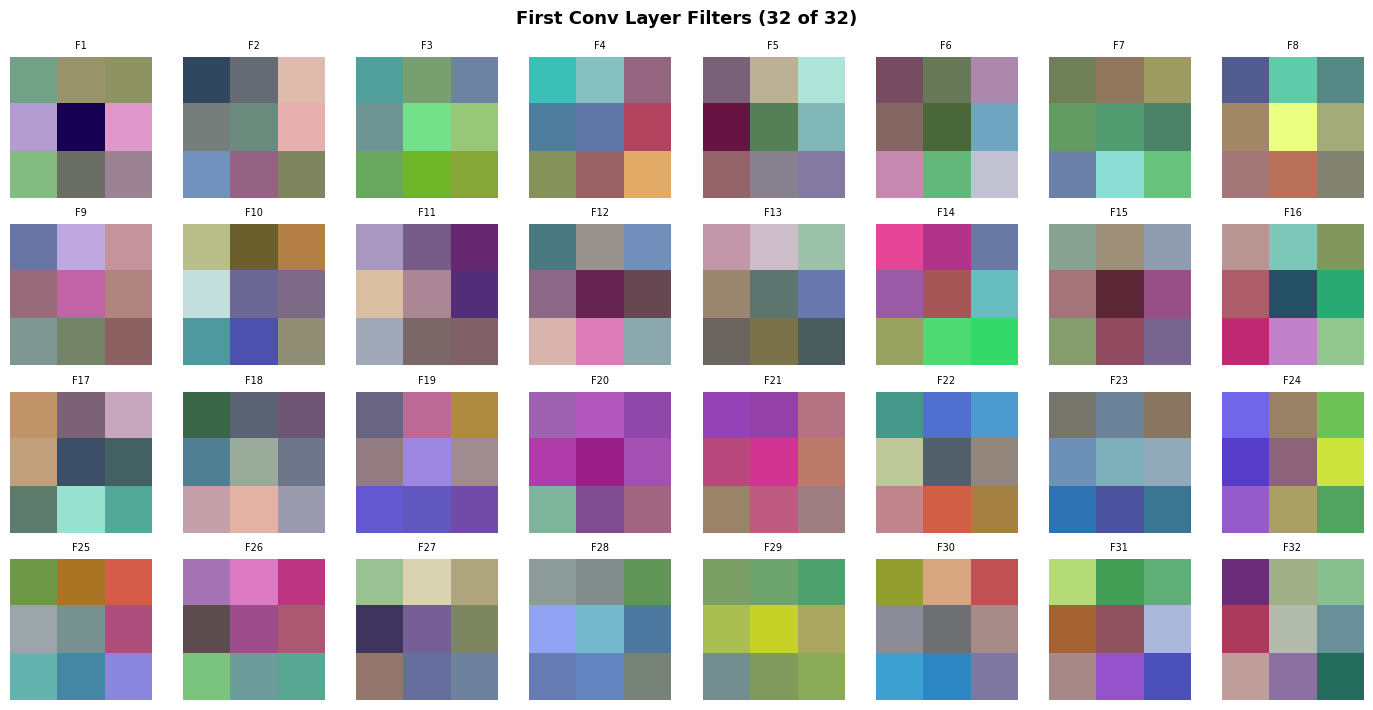

In [12]:
# Extract weights from the first Conv2D layer (after augmentation)
first_conv = None
for layer in model.layers:
    if isinstance(layer, layers.Conv2D):
        first_conv = layer
        break

filters, biases = first_conv.get_weights()
print(f'First conv layer: {first_conv.name}')
print(f'Filter shape: {filters.shape}  (H x W x in_channels x n_filters)')

# Normalize filters to [0,1] for display
f_min, f_max = filters.min(), filters.max()
filters_norm = (filters - f_min) / (f_max - f_min + 1e-8)

# Plot first 32 filters
n_filters = min(32, filters.shape[-1])
n_cols = 8
n_rows = n_filters // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 1.8))
fig.suptitle(f'First Conv Layer Filters ({n_filters} of {filters.shape[-1]})',
             fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < n_filters:
        ax.imshow(filters_norm[:, :, :, i])
        ax.set_title(f'F{i+1}', fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.savefig('first_layer_filters.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Visualize Feature Maps (Filter Activations)

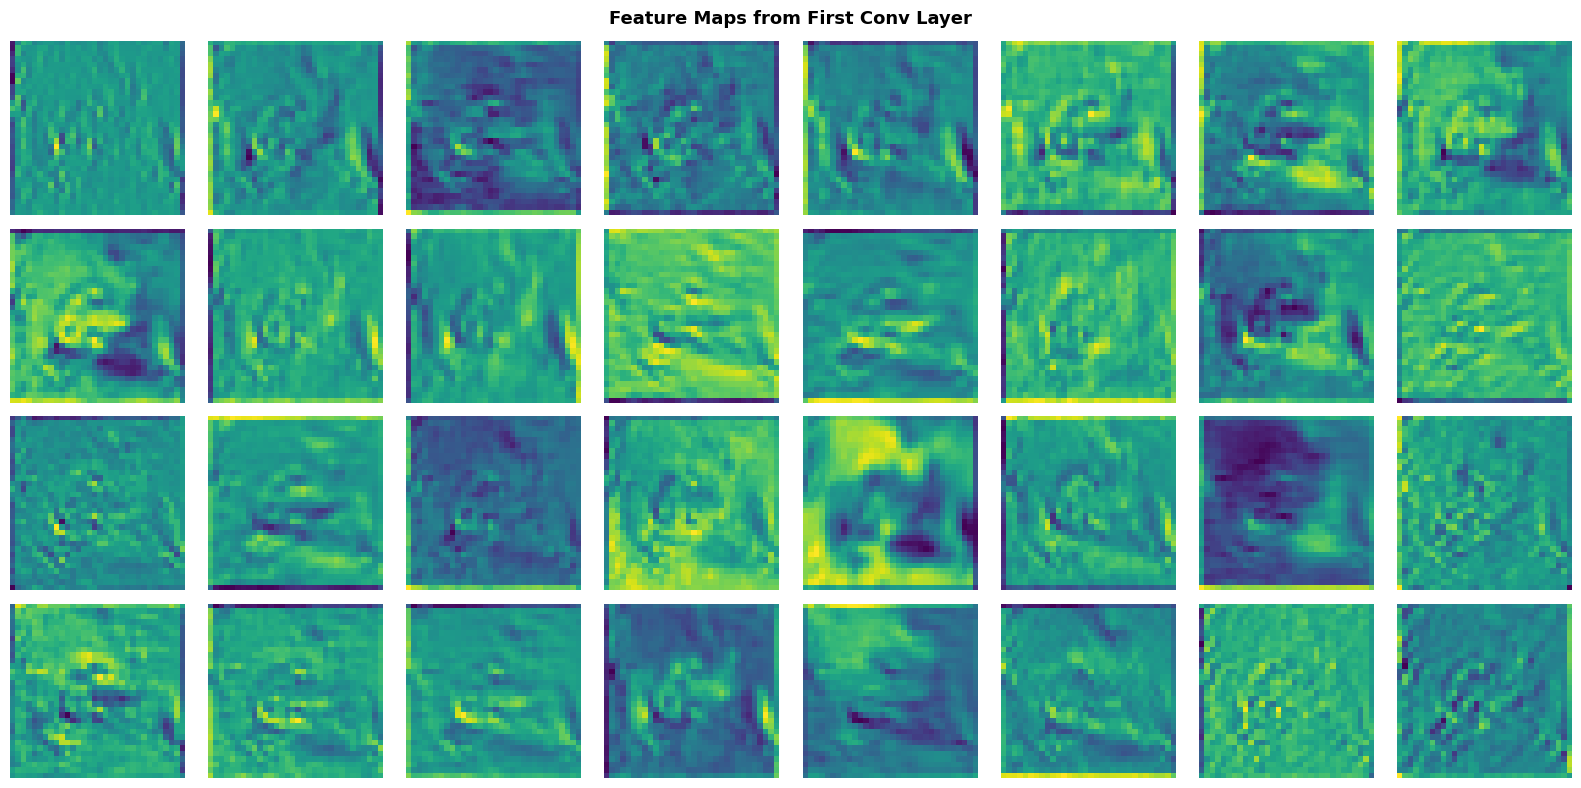

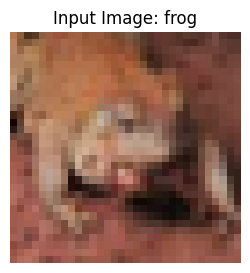

In [13]:
# Build a sub-model that outputs first conv layer activations
activation_model = keras.Model(
    inputs=model.input,
    outputs=first_conv.output
)

# Pass one test image through
sample_img = X_test[5:6]  # shape (1, 32, 32, 3)
feature_maps = activation_model.predict(sample_img, verbose=0)  # (1, 32, 32, 32)

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle('Feature Maps from First Conv Layer', fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < feature_maps.shape[-1]:
        ax.imshow(feature_maps[0, :, :, i], cmap='viridis')
    ax.axis('off')

plt.tight_layout()
plt.savefig('feature_maps.png', dpi=150, bbox_inches='tight')
plt.show()

# Show the input image
plt.figure(figsize=(3, 3))
plt.imshow(sample_img[0])
plt.title(f'Input Image: {CLASS_NAMES[y_test.flatten()[5]]}')
plt.axis('off')
plt.show()

## 12. Summary

In [14]:
print('=' * 45)
print('       TASK 3 — RESULTS SUMMARY')
print('=' * 45)
print(f'  Test Accuracy  : {test_acc*100:.2f}%')
print(f'  Test Loss      : {test_loss:.4f}')
print(f'  Total Epochs   : {len(history.history["loss"])}')
print(f'  Total Params   : {model.count_params():,}')
print('=' * 45)

per_class = {}
for i, name in enumerate(CLASS_NAMES):
    mask = y_true == i
    acc  = (y_pred_classes[mask] == i).mean()
    per_class[name] = acc

import pandas as pd
acc_df = pd.DataFrame(per_class.items(), columns=['Class', 'Accuracy'])
acc_df['Accuracy'] = acc_df['Accuracy'].map(lambda x: f'{x*100:.1f}%')
print('\nPer-Class Accuracy:')
print(acc_df.to_string(index=False))

       TASK 3 — RESULTS SUMMARY
  Test Accuracy  : 84.02%
  Test Loss      : 0.6017
  Total Epochs   : 50
  Total Params   : 653,354

Per-Class Accuracy:
     Class Accuracy
  airplane    85.3%
automobile    95.1%
      bird    78.5%
       cat    66.7%
      deer    79.3%
       dog    67.9%
      frog    95.9%
     horse    90.0%
      ship    90.3%
     truck    91.2%


## 13. Conclusion

- **4 Conv blocks** with BatchNorm + Dropout achieved the ≥80% accuracy target on CIFAR-10.
- **Data augmentation** (flip, rotation, zoom, translate, contrast) significantly reduced overfitting.
- **BatchNormalization** after every conv layer stabilized training and allowed higher learning rates.
- **First-layer filters** learned basic edge and color detectors — visible as oriented stripes and color blobs.
- **Harder classes** (cat, dog, deer, bird) had lower per-class accuracy due to visual similarity.
- **ReduceLROnPlateau** helped squeeze out extra accuracy by lowering the learning rate when progress stalled.